In [ ]:
import matplotlib.pyplot as plt
import numpy as np



plt.style.use('../my_style.mplstyle')

r = 0.59
d = 0.025
dna = 0.010

f = 1.13e-2

k_cargo = 2.26e-2
v = 0.5
tau = d/v

def dna_potential_gaussian(f, x, r):
    r_a = np.sqrt(2 * r * d / (1 + d/r)**2)
    cutoff = np.sqrt((d+2*dna)*(2*r+2*dna))/(1+(2*dna+d/2)/r)
    epsilon = np.sqrt(np.exp(1)/2) * r_a * f 
    if np.abs(x) <= cutoff:
        return -epsilon * np.exp(-(x**2)/(r_a**2))
    else:
        return 0

def dna_force_gaussian(f, x, r):
    r_a = np.sqrt(2 * r * d / (1 + d/r)**2)
    cutoff = np.sqrt((d+2*dna)*(2*r+2*dna))/(1+(2*dna+d/2)/r)
    epsilon = np.sqrt(np.exp(1)/2) * r_a * f 
    if np.abs(x) <= cutoff:
        return -2 * epsilon * x * np.exp(-(x**2)/(r_a**2)) / (r_a**2)
    else:
        return 0

coefficient = tau / (k_cargo * d)

#print("Coefficient:", epsilon*coefficient)

distances = np.linspace(0, 1.0, 1000)

fig, ax = plt.subplots()

ax.plot(distances, [dna_potential_gaussian(f*coefficient, x, 0.5) for x in distances], label='0.5')
ax.plot(distances, [dna_potential_gaussian(f*coefficient, x, 5.0) for x in distances], label='5.0')

ax.set_xlabel('Distance $\\tilde{r}_\mathrm{ci}$')
ax.set_ylabel('potential')
#ax.set_ylim(-1.1*f*coefficient, 0.1)
ax.legend()
plt.show()
"""
fig.savefig('figures/dna_potential_gaussian.png', bbox_inches='tight')
fig.savefig('figures/dna_potential_gaussian.pdf', bbox_inches='tight')
"""

In [ ]:
def dna_force_gaussian(f, x, r):
    r_a = np.sqrt(2 * r * d / (1 + d/r)**2)
    cutoff = np.sqrt((d+2*dna)*(2*r+2*dna))/(1+(2*dna+d/2)/r)
    epsilon = np.sqrt(np.exp(1)/2) * r_a * f 
    if np.abs(x) <= cutoff:
        return -2 * epsilon * x * np.exp(-(x**2)/(r_a**2)) / (r_a**2)
    else:
        return 0

coefficient = tau / (k_cargo * d)

#print("Coefficient:", epsilon*coefficient)

distances = np.linspace(0, 1.0, 1000)

fig, ax = plt.subplots()

ax.plot(distances, [dna_force_gaussian(f*coefficient, x, 0.5) for x in distances], label='0.5')
ax.plot(distances, [dna_force_gaussian(f*coefficient, x, 5.0) for x in distances], label='5.0')

ax.set_xlabel('force')
ax.set_ylabel('potential')
#ax.set_ylim(-1.1*f*coefficient, 0.1)
ax.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

plt.style.use('../my_style.mplstyle')

r = 0.59
d = 0.025
l = 0.010
r_a = np.sqrt(2 * r * d / (1 + d/r)**2)
r_dna = np.sqrt((d+2*l)*(2*r+2*l))/(r*(1+(2*l+d/2)/r))

f = 1.13e-2
epsilon = np.sqrt(np.exp(1)/2) * r_a * f 

k_cargo = 2.26e-2
v = 0.5
tau = r/v

In [ ]:
def dna_force_gaussian(epsilon, r, r_a):
    return -2 * epsilon * r * np.exp(-(r**2)/(r_a**2)) / (r_a**2)

def dna_force(f, r, r_a):
    if r < r_a:
        return -f
    else:
        return 0.0

def dna_force_spring(f, r, r_a, r_dna):
    if r < r_a:
        return -f
    elif r_a <= r < r_dna:
        return -f * (r_dna - r) / (r_dna - r_a)
    else:
        return 0.0
    
def spring_force(f, r, r_a):
    if r < r_a:
        return -f * r/r_a
    else:
        return 0

def Lennard_force(epsilon, r, sigma):
    return -4 * epsilon * ((-12 * (sigma**12) / (r**13)) + (6 * (sigma**6) / (r**7)))



LJ_e = (13/144) * ((26/7)**(7/6)) * r_a * f

coefficient = tau / (k_cargo * r)

print("Coefficient:", f*coefficient)

distances = np.linspace(0, 1.0, 500)

fig, ax = plt.subplots()

ax.plot(distances, [dna_force(f*coefficient, r, r_a) for r in distances], label='Step')
#ax.plot(distances, [dna_force_spring(f*coefficient, r, r_a, r_dna) for r in distances], label='DNA spring')
ax.plot(distances, [spring_force(f*coefficient, r, r_a) for r in distances], label='Linear spring')
ax.plot(distances, [dna_force_gaussian(epsilon*coefficient, r, r_a) for r in distances], label='Gaussian')

LJ_distances = distances[distances > r_a*0.9]

ax.plot(LJ_distances, [Lennard_force(LJ_e*coefficient, r, r_a) for r in LJ_distances], label='Lennard-Jones')

ax.axvline(r_a, color='black', lw=1, ls='--')
#ax.axvline(r_dna, color='black', lw=1, ls='--')

ax.text(r_a + 0.02, -1.07*f*coefficient, '$\\tilde{r}_\mathrm{a}$')
#ax.text(r_dna + 0.02, -f*coefficient, '$\hat{r}_\mathrm{dna}$')

ax.set_xlabel('Distance $\\tilde{r}_\mathrm{ci}$')
ax.set_ylabel('$F\\tau/R k_c$')
ax.set_ylim(-1.1*f*coefficient, 0.1)
ax.legend()
plt.show()

fig.savefig('../figures/dna_force_comparison.png', bbox_inches='tight')
fig.savefig('../figures/dna_force_comparison.pdf', bbox_inches='tight')

In [ ]:
def dna_force_gaussian(epsilon, r, r_a):
    return -epsilon * np.exp(-(r**2)/(r_a**2))

def dna_force(f, r, r_a):
    if r < r_a:
        return f * (r-r_a)
    else:
        return 0.0

def dna_force_spring(f, r, r_a, r_dna):
    if r < r_a:
        return -f
    elif r_a <= r < r_dna:
        return -f * (r_dna - r) / (r_dna - r_a)
    else:
        return 0.0
    
def spring_force(f, r, r_a):
    if r < r_a:
        return f * (r-r_a)**2/(2*r_a)
    else:
        return 0

def Lennard_force(epsilon, r, sigma):
    return 4 * epsilon * (((sigma**12) / (r**12)) - ((sigma**6) / (r**6)))



LJ_e = (13/144) * ((26/7)**(7/6)) * r_a * f

coefficient = tau / (k_cargo * r)

print("Coefficient:", f*coefficient)

distances = np.linspace(0, 1.0, 500)

fig, ax = plt.subplots()

ax.plot(distances, [dna_force(f*coefficient, r, r_a) for r in distances], label='Step')
#ax.plot(distances, [dna_force_spring(f*coefficient, r, r_a, r_dna) for r in distances], label='DNA spring')
ax.plot(distances, [spring_force(f*coefficient, r, r_a) for r in distances], label='Linear spring')
ax.plot(distances, [dna_force_gaussian(epsilon*coefficient, r, r_a) for r in distances], label='Gaussian')

ax.plot(distances, [Lennard_force(LJ_e*coefficient, r, r_a) for r in distances], label='Lennard-Jones')

ax.axvline(r_a, color='black', lw=1, ls='--')
#ax.axvline(r_dna, color='black', lw=1, ls='--')

ax.text(r_a + 0.02, -0.19, '$\\tilde{r}_\mathrm{a}$')
#ax.text(r_dna + 0.02, -f*coefficient, '$\hat{r}_\mathrm{dna}$')

ax.set_xlabel('Distance $\\tilde{r}_\mathrm{ci}$')
ax.set_ylabel('Potential $\\tilde{U}$')
ax.set_ylim(-0.2, 0.1)
ax.legend()
plt.show()

fig.savefig('../figures/dna_force_comparison.png', bbox_inches='tight')
fig.savefig('../figures/dna_force_comparison.pdf', bbox_inches='tight')


In [ ]:
def dna_force_gaussian(epsilon, r, r_a, cutoff):
    if r - r_a <= cutoff:
        return -2 * epsilon * r * np.exp(-(r**2)/(r_a**2)) / (r_a**2)
    else:
        return 0

coefficient = tau / (k_cargo * r)

print("Coefficient:", f*coefficient)

distances = np.linspace(0, 1.0, 500)

fig, ax = plt.subplots()

ax.plot(distances, [dna_force(f*coefficient, r, r_a) for r in distances], label='Step')

ax.axvline(r_a, color='black', lw=1, ls='--')
#ax.axvline(r_dna, color='black', lw=1, ls='--')

ax.text(r_a + 0.02, -1.07*f*coefficient, '$\\tilde{r}_\mathrm{a}$')
#ax.text(r_dna + 0.02, -f*coefficient, '$\hat{r}_\mathrm{dna}$')

ax.set_xlabel('Distance $\\tilde{r}_\mathrm{ci}$')
ax.set_ylabel('$F\\tau/R k_c$')
ax.set_ylim(-1.1*f*coefficient, 0.1)
ax.legend()
plt.show()

fig.savefig('../figures/dna_force_comparison.png', bbox_inches='tight')
fig.savefig('../figures/dna_force_comparison.pdf', bbox_inches='tight')

[(-1.5, 0.1)]

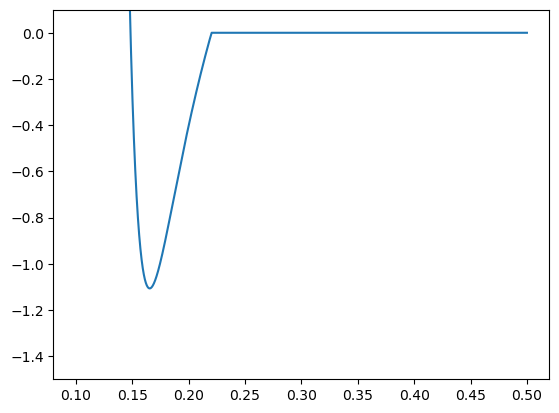

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def LJ(r, epsilon, sigma):
    return 4 * epsilon * (((sigma**12) / (r**12)) - ((sigma**6) / (r**6)))

def dot_LJ(r, epsilon, sigma):
    return -4 * epsilon * ((-12 * (sigma**12) / (r**13)) + (6 * (sigma**6) / (r**7)))

def LJ_fs(r, epsilon, sigma, r_cut):
    # np.where を用いて配列に対応
    return np.where(r <= r_cut, 
                    LJ(r, epsilon, sigma) - LJ(r_cut, epsilon, sigma) - (r-r_cut) * dot_LJ(r_cut, epsilon, sigma), 
                    0)

radius = 0.59
d=0.025
l=0.01

r = np.linspace(1e-1, 0.5, 50000) # 0割りを回避するために0より少し大きい値から開始
r_0 = np.sqrt(2 * radius * d / (1+d/(2*radius))**2)
r_cut = np.sqrt((d+2*l) * (2*radius+2*l) / (1+(2*l+d/2)/radius)**2) 

fig, ax = plt.subplots()
ax.plot(r, LJ_fs(r, 1, r_0*(2**(-1/6)), r_cut))

ax.set(ylim = (-1.5, 0.1))

[(-8.0, 1.0)]

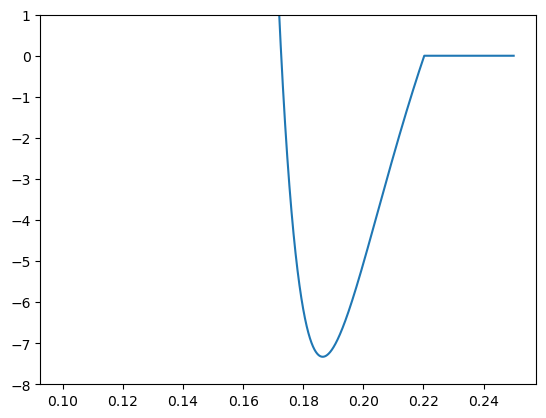

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def LJ(r, epsilon, sigma):
    return 4 * epsilon * (((sigma**12) / (r**12)) - ((sigma**6) / (r**6)))

def dot_LJ(r, epsilon, sigma):
    return -4 * epsilon * ((-12 * (sigma**12) / (r**13)) + (6 * (sigma**6) / (r**7)))

def LJ_fs(r, epsilon, sigma, r_cut):
    # np.where を用いて配列に対応
    return np.where(r <= r_cut, 
                    LJ(r, epsilon, sigma) - LJ(r_cut, epsilon, sigma) - (r-r_cut) * dot_LJ(r_cut, epsilon, sigma), 
                    0)

def dot_LJ_fs(r, epsilon, sigma, r_cut):
    # np.where を用いて配列に対応
    return np.where(r <= r_cut, 
                    dot_LJ(r, epsilon, sigma) - dot_LJ(r_cut, epsilon, sigma), 
                    0)

def dot_LJ_ts(r, epsilon, sigma, r_cut):
    # np.where を用いて配列に対応
    return np.where(r <= r_cut, 
                    dot_LJ(r, epsilon, sigma), 
                    0)

radius = 0.59
d=0.025
l=0.01

r = np.linspace(1e-1, 0.25, 50000) # 0割りを回避するために0より少し大きい値から開始
r_0 = np.sqrt(2 * radius * d / (1+d/(2*radius))**2)
r_cut = np.sqrt((d+2*l) * (2*radius+2*l) / (1+(2*l+d/2)/radius)**2) 

fig, ax = plt.subplots()
ax.plot(r, dot_LJ_fs(r, 1, r_0*(2**(-1/6)), r_cut))

ax.set(ylim = (-8, 1))